In [1]:
# %matplotlib widget
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import open_dict
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

from boa.model.module import ChgLightningModule

from mldft.ml.data.components.convert_transforms import ToTorch
from mldft.ml.data.components.of_data import Representation
from mldft.ml.models.components.loss_function import project_gradient
from mldft.utils.instantiators import instantiate_datamodule

In [2]:
device = "cuda"

with initialize(version_base=None, config_path="../configs"):
    config = compose(
        config_name="test.yaml",
        overrides=[
            "eval=qm9_pyscf_small",
            "data.datamodule.batch_size.val=1"
        ],
    )

basis_info = instantiate(config.data.basis_info)
datamodule_config = config.data.datamodule.copy()

datamodule = instantiate(datamodule_config, _recursive_=False)
datamodule.setup(stage="fit")

val_set = datamodule.val_dataset
train_set = datamodule.train_dataset
test_set = datamodule.test_dataset

In [3]:
# Load model and hooks in same cell to not hook multiple times
checkpoint_path = config.ckpt_path[0]
best_model_path = Path(config.ckpt_path[0]) / "best_model_path.txt"
if best_model_path.exists():
    # check if the best_model_path is different from the ckpt_path
    with open(best_model_path, "r") as f:
        best_ckpt_path = f.read().strip()
else:
    raise FileNotFoundError("Best model path not found")
lightning_module = ChgLightningModule.load_from_checkpoint(
    best_ckpt_path, map_location=device
)
lightning_module.eval()

inputs = []
outputs = []
def hook_fn(module, input, output):
    inputs.append(input[0].detach().cpu())
    outputs.append(output.detach().cpu())
lightning_module.model.boa_stack.blocks[2].message_pass.register_forward_hook(hook_fn)

/export/home/mickler/boa/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Unique atom types: [1 6 7 8 9]
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
self.linear_basis: False
self.linear_basis: False


In [4]:
# Clear hook storage before running
inputs.clear()
outputs.clear()

sample = test_set[4].to(device)
with torch.no_grad():
    coeffs, edge_index = lightning_module.model(sample)

In [5]:
print(len(inputs), len(outputs))
print(inputs[0].shape, outputs[0].shape)
print("natoms", sample.atomic_numbers)

1 1
torch.Size([941, 32]) torch.Size([941, 32])
natoms tensor([6, 6, 6, 7, 6, 6, 7, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0',
       dtype=torch.int32)


In [11]:
# Select sending (b) and receiving (a) atoms
atom_a_idx = 0
atom_b_idx = 1
print(f"Atom type of atom a: {sample.atomic_numbers[atom_a_idx].item()} and atom b: {sample.atomic_numbers[atom_b_idx].item()}")
coeff_ind_to_node_ind = sample.coeff_ind_to_node_ind.cpu()
node_features = inputs[0] # Shape: (total_basis_funcs, channels)
mask_b = (coeff_ind_to_node_ind == atom_b_idx)
h_b = node_features[mask_b] # Shape: (basis_dim_b, channels)

mask_a = (coeff_ind_to_node_ind == atom_a_idx)
h_a = node_features[mask_a]

# Find the edge index for b -> a in message_edge_index
edge_indices = sample.message_edge_index.cpu()
edge_idx = -1
for i in range(edge_indices.shape[1]):
    if edge_indices[0, i] == atom_a_idx and edge_indices[1, i] == atom_b_idx:
        edge_idx = i
        break
print(f"Bond found at edge index: {edge_idx}")
W_ab = sample.message_edge_matrices[edge_idx].cpu()

# Slice W_ab to actual dimensions
dim_a = h_a.shape[0]
dim_b = h_b.shape[0]
W_ab = W_ab[:dim_a, :dim_b]

# 3. Compute overlap o_ab = W_ab @ h_b
o_ab = torch.matmul(W_ab, h_b)

# 4. Get inverse overlap matrix of receiving node a: (W_aa)^-1
atom_type_a = sample.atomic_numbers[atom_a_idx].item()
inv_W_aa = lightning_module.model.boa_stack.inv_overlap_matrices[atom_type_a].cpu()

# 5. Compute message m_ab = (W_aa)^-1 @ o_ab
m_ab = torch.matmul(inv_W_aa, o_ab)

Atom type of atom a: 6 and atom b: 6
Bond found at edge index: 26


In [54]:
from pyscf import dft
from mldft.utils.molecules import build_molecule_ofdata

atom_c_idx = 2

# build grid using meshgrid on a plane through three atoms
pos1 = sample.pos[atom_a_idx].cpu().detach().numpy()
pos2 = sample.pos[atom_b_idx].cpu().detach().numpy()
pos3 = sample.pos[atom_c_idx].cpu().detach().numpy()

# calculate the normal vector of the plane defined by the three points
normal_vector = np.cross(pos2 - pos1, pos3 - pos1)
normal_vector /= np.linalg.norm(normal_vector)
# calculate the center of the three points
center = (pos1 + pos2 + pos3) / 3
# rotate the grid points to align with the normal vector
rot_vec1 = pos2 - pos1
rot_vec1 /= np.linalg.norm(rot_vec1)
rot_vec2 = np.cross(rot_vec1, normal_vector)
rot_vec3 = normal_vector

rot_mat = np.array([rot_vec1, rot_vec2, rot_vec3]).T

# Project all atoms to the plane to find the bounds
all_pos = sample.pos.detach().cpu().numpy()
local_pos = (all_pos - center) @ rot_mat
x_min, y_min = local_pos[:, :2].min(axis=0)
x_max, y_max = local_pos[:, :2].max(axis=0)

# Center the grid on the molecule's projection
center_x = (x_min + x_max) / 2
center_y = (y_min + y_max) / 2
width_x = x_max - x_min
width_y = y_max - y_min
max_width = max(width_x, width_y)
padding = 4.0 
half_size = max_width / 2 + padding

# create a grid of points in the plane
grid_size = 100
grid_points_x = np.linspace(center_x - half_size, center_x + half_size, grid_size)
grid_points_y = np.linspace(center_y - half_size, center_y + half_size, grid_size)
# grid_points_x = np.linspace(-15, 15, grid_size)
# grid_points_y = np.linspace(-15, 15, grid_size)

x, y = np.meshgrid(grid_points_x, grid_points_y)

print(sample.pos.shape)
print(sample.pos)

grid_points_local = np.array([x.flatten(), y.flatten(), np.zeros_like(x.flatten())]).T
grid_points = (rot_mat @ grid_points_local.T).T + center

mol = build_molecule_ofdata(sample, basis_info.basis_dict)
# Convert grid points to Bohr for PySCF evaluation (1 Angstrom = 1.889726 Bohr)
BOHR = 1.8897259886
aos_mol = torch.as_tensor(dft.numint.eval_ao(mol, grid_points * BOHR, deriv=0))
print(aos_mol.shape)

torch.Size([17, 3])
tensor([[5.1589, 5.2799, 3.4346],
        [5.0893, 3.7690, 3.3405],
        [6.1376, 3.0622, 2.5515],
        [6.1382, 2.9840, 4.0236],
        [3.7346, 3.1166, 3.4246],
        [2.5358, 3.8045, 3.9653],
        [2.6343, 3.5034, 2.5243],
        [6.1715, 5.6338, 3.2197],
        [4.4877, 5.7690, 2.7190],
        [4.8838, 5.6260, 4.4367],
        [5.9009, 2.1297, 2.0462],
        [6.8966, 3.6634, 2.0572],
        [6.8447, 3.6099, 4.4033],
        [3.8104, 2.0420, 3.5719],
        [1.7817, 3.2350, 4.5012],
        [2.6293, 4.8374, 4.2878],
        [2.8839, 4.3486, 2.0154]], device='cuda:0')
torch.Size([10000, 941])


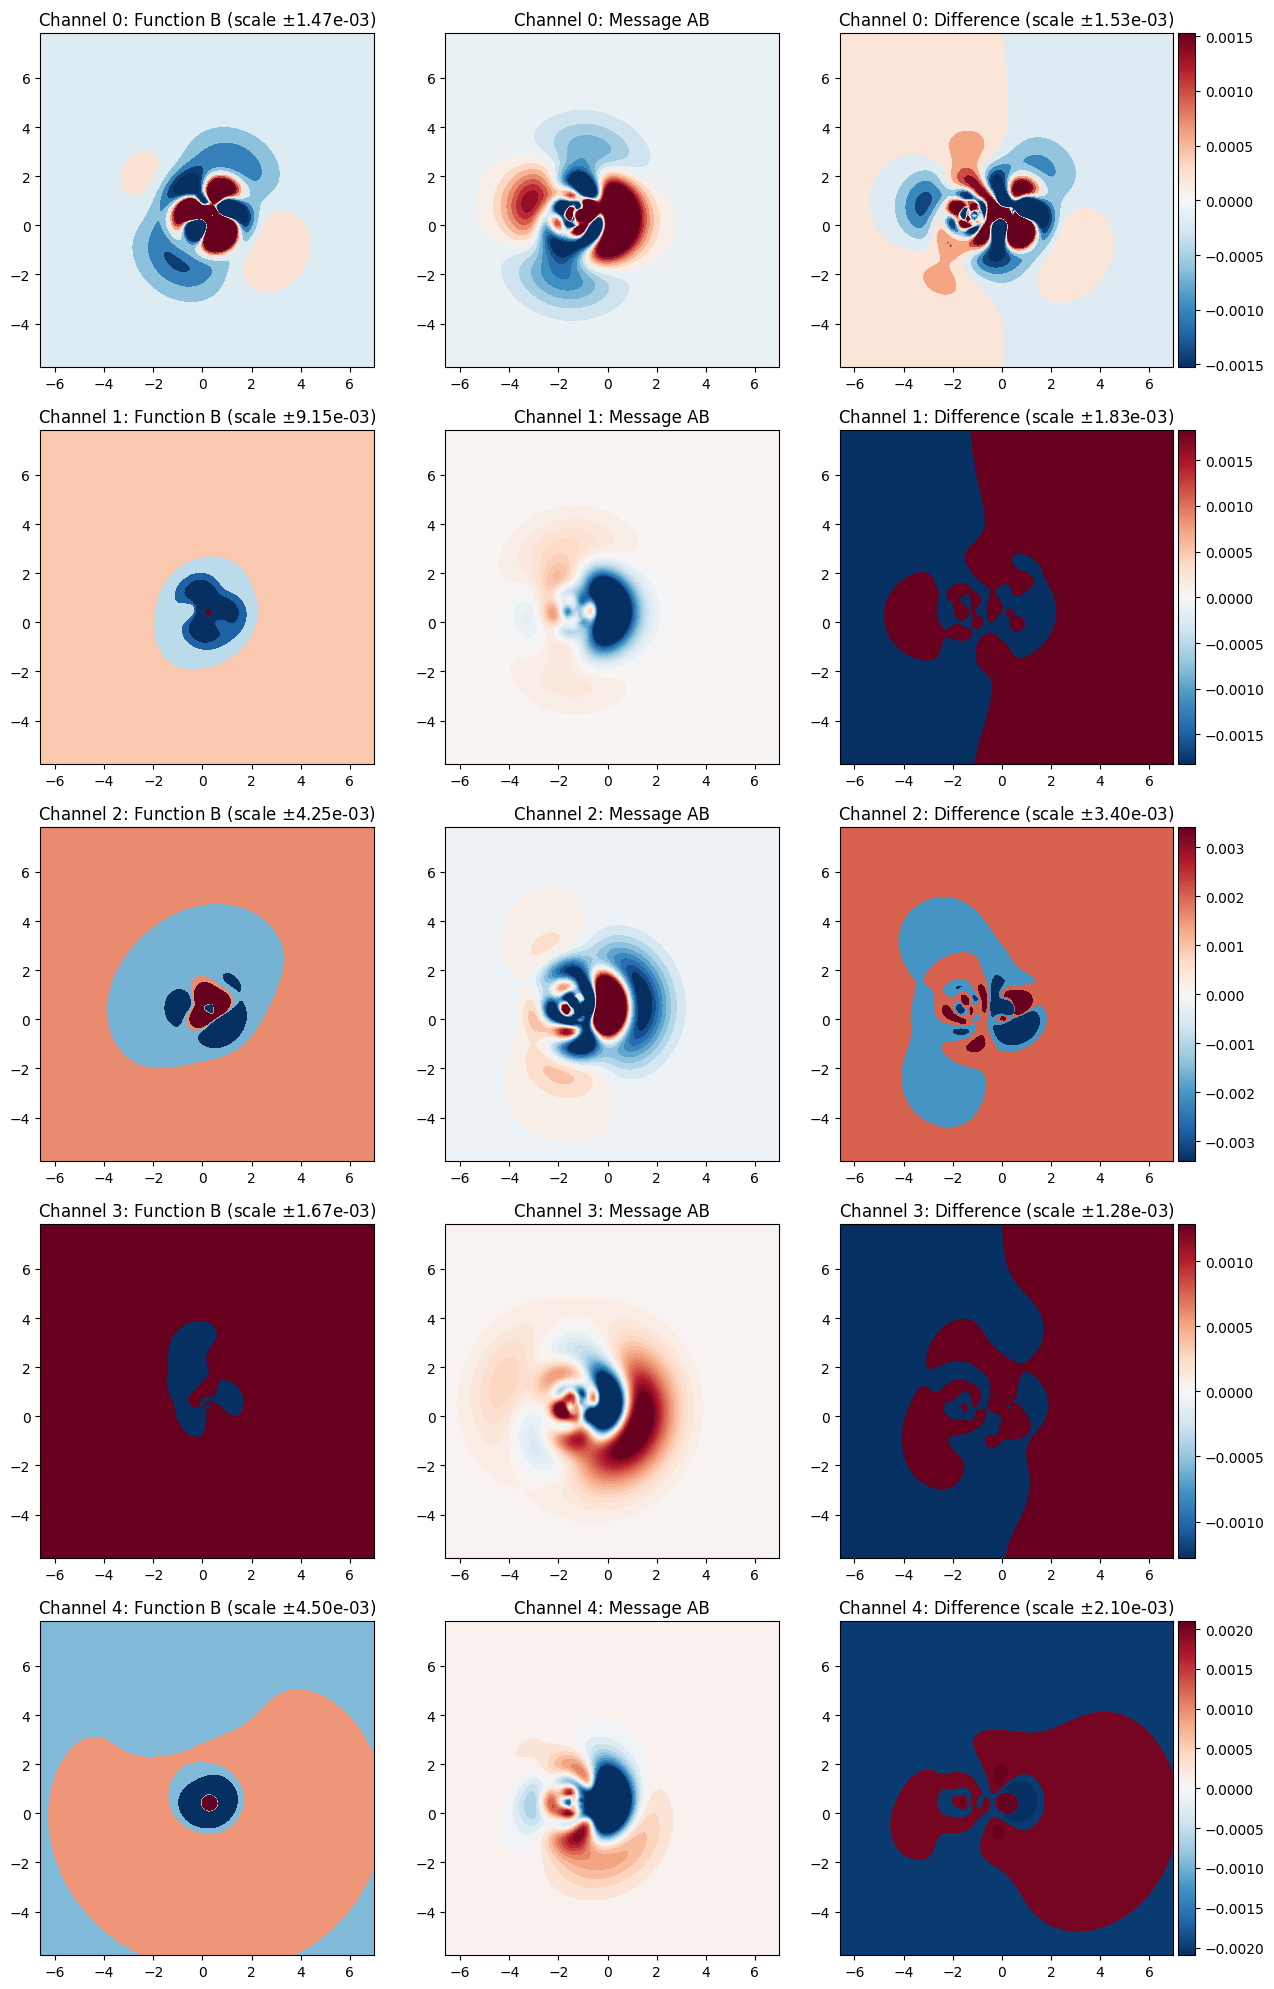

In [62]:
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

n_rows = 5
offset = 0
fig, axs = plt.subplots(n_rows, 3, figsize=(13, 20))

for i, channel_idx in enumerate(range(offset, n_rows + offset)):
    function_a_channel = torch.einsum('j, ij->i', h_a[:, channel_idx].double(), aos_mol[:, coeff_ind_to_node_ind==atom_a_idx])
    function_b_channel = torch.einsum('j, ij->i', h_b[:, channel_idx].double(), aos_mol[:, coeff_ind_to_node_ind==atom_b_idx])
    message_ab_channel = torch.einsum('j, ij->i', m_ab[:, channel_idx].double(), aos_mol[:, coeff_ind_to_node_ind==atom_a_idx])
    
    # Calculate difference
    diff_channel = function_b_channel - message_ab_channel
    
    # Calculate shared color limits using percentiles to avoid outliers
    all_values = torch.cat([function_b_channel, message_ab_channel])
    vmin = torch.quantile(all_values, 0.02).item()
    vmax = torch.quantile(all_values, 0.98).item()
    
    # Use symmetric limits around zero for diverging colormap
    vabs = max(abs(vmin), abs(vmax))
    vmin, vmax = -vabs, vabs

    axs[i, 0].contourf(x, y, function_b_channel.reshape(grid_size, grid_size), levels=100, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    axs[i, 0].set_aspect('equal')
    axs[i, 0].set_title(f'Channel {channel_idx}: Function B (scale $\pm${vabs:.2e})')

    axs[i, 1].contourf(x, y, message_ab_channel.reshape(grid_size, grid_size), levels=100, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    axs[i, 1].set_aspect('equal')
    axs[i, 1].set_title(f'Channel {channel_idx}: Message AB')
    
    # Calculate symmetric limits for difference plot using percentiles to avoid outliers
    diff_vmin_p = torch.quantile(diff_channel, 0.02).item()
    diff_vmax_p = torch.quantile(diff_channel, 0.98).item()
    diff_abs = max(abs(diff_vmin_p), abs(diff_vmax_p))
    diff_vmin, diff_vmax = -diff_abs, diff_abs
    
    im_diff = axs[i, 2].contourf(x, y, diff_channel.reshape(grid_size, grid_size), levels=100, vmin=diff_vmin, vmax=diff_vmax, cmap='RdBu_r')
    axs[i, 2].set_aspect('equal')
    axs[i, 2].set_title(f'Channel {channel_idx}: Difference (scale $\pm${diff_abs:.2e})')
    
    # Add colorbar to the difference plot
    divider = make_axes_locatable(axs[i, 2])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=diff_vmin, vmax=diff_vmax)), cax=cax, fraction=0.1, pad=0.05)

plt.tight_layout()

Minimum distance between atoms and grid points: [0.03689341 0.03810249 0.05096529 1.21532444 0.64900204 0.93639199
 2.03946644 0.37315468 1.00605123 0.64090054 0.47853047 0.0368687
 1.87820079 0.40084802 0.87966877 0.69769237 2.38050563]


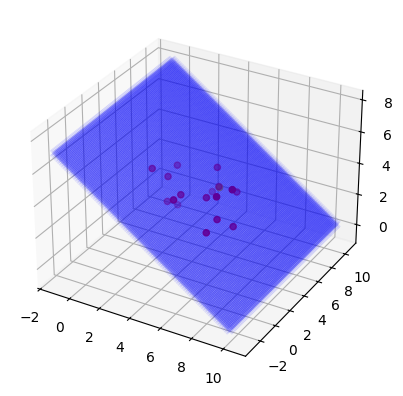

In [56]:
# plot atoms and grid points in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
atom_pos = sample.pos.cpu().detach().numpy()
ax.scatter(grid_points[:, 0], grid_points[:, 1], grid_points[:, 2], c='b', marker='x', label='Grid Points', alpha=0.1)
ax.scatter(atom_pos[atom_a_idx, 0], atom_pos[atom_a_idx, 1], atom_pos[atom_a_idx, 2], c='gold', label='Atoms')

ax.scatter(atom_pos[:, 0], atom_pos[:, 1], atom_pos[:, 2], c='r', marker='o', label='Atoms') 

# print minimum distance between atoms and grid points
min_dist = np.min(np.linalg.norm(atom_pos[:, None, :] - grid_points[None, :, :], axis=-1), axis=1)
print("Minimum distance between atoms and grid points:", min_dist)

rot_pos = (rot_mat.T @ (sample.pos.detach().cpu().numpy() - center).T).T
rot_pos_xy = rot_pos[:, :2]

### Visualizing Single Message Passing
The hooks you defined above capture the **aggregated** messages (summed over all neighbors) because `MessagePassAttention` aggregates the messages using `index_add` before returning, and `InverseMultAtom` is applied to these aggregated values.

To visualize the message transformation for a **single edge** (e.g., from atom $b$ to atom $a$), we need to manually compute the message $m_{ab}$ using the node features and the overlap matrices, as the individual edge messages are not exposed by the module's output.

The code below demonstrates how to:
1. Select a specific edge (from atom 1 to atom 0).
2. Extract the features of the sending node ($h_b$).
3. Compute the overlap $o_{ab} = W^{ab} h_b$.
4. Compute the message in the receiving basis $m_{ab} = (W^{aa})^{-1} o_{ab}$.
5. Evaluate and plot both $h_b$ and $m_{ab}$ on the grid to compare them.